# Random Forest — Benchmarking Non-Linear Structure in ED Wait Times

Fits `RandomForestRegressor` on the same Model 1 (demographic + access) and
Model 2 (+ clinical) feature matrices used in `linear_regression.ipynb` and
`lasso_regression.ipynb`. Per `MODELING.md` Step 5, Random Forest is used
here for two things OLS/Lasso can't do: capture non-linear relationships
and interactions, and benchmark whether the linear models' low R² reflects
a genuinely noisy outcome or a poor functional-form assumption.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

m1 = pd.read_csv("../data/processed/nhamcs_model1_encoded.csv")
m2 = pd.read_csv("../data/processed/nhamcs_model2_encoded.csv")

print(f"Model 1 (demographic + access): {m1.shape[0]:,} rows x {m1.shape[1]} cols")
print(f"Model 2 (+ clinical): {m2.shape[0]:,} rows x {m2.shape[1]} cols")

Model 1 (demographic + access): 329,249 rows x 47 cols
Model 2 (+ clinical): 329,249 rows x 56 cols


Split (no scaling this time)

Same 80/20 split, `random_state=42`, and target (`log_wait_time`) as the
other two notebooks. **Deliberate deviation from `MODELING.md` Step 2:**
this notebook skips `StandardScaler`. Random forests split on the *rank
order* of a feature's values, not their magnitude, so scaling numeric
columns changes nothing about the fitted model, its predictions, or its
feature importances — it would only cost us interpretable units
(`survey_year` as 2007-2022 instead of a z-score) on the partial-dependence
plots below. This is safe specifically because trees are scale-invariant;
it would *not* be safe for the OLS/Lasso notebooks, where scaling affects
coefficient interpretation directly.

In [2]:
from sklearn.model_selection import train_test_split

TARGET = "log_wait_time"
DROP = ["wait_time_min", "log_wait_time"]

X1 = m1.drop(columns=DROP)
X2 = m2.drop(columns=DROP)
y = m1[TARGET]  # same rows in both files, so y is identical

X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)
X2_train, X2_test, _, _ = train_test_split(X2, y, test_size=0.2, random_state=42)

print(f"Model 1: X_train {X1_train.shape}, X_test {X1_test.shape}")
print(f"Model 2: X_train {X2_train.shape}, X_test {X2_test.shape}")

Model 1: X_train (263399, 45), X_test (65850, 45)
Model 2: X_train (263399, 54), X_test (65850, 54)


Fit Random Forest

`n_estimators=200, max_depth=12, min_samples_leaf=50` — the depth cap and
leaf-size floor from `MODELING.md` keep the forest from overfitting to
individual visits given 329k rows and a noisy target.

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import time


def evaluate(model, X_test, y_test, label):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae_log = mean_absolute_error(y_test, preds)
    # Back-transform to minutes for interpretability
    mae_min = mean_absolute_error(np.expm1(y_test), np.expm1(preds))
    print(f"{label}: R2={r2:.4f}  MAE(log)={mae_log:.4f}  MAE(min)={mae_min:.1f}")
    return preds


t0 = time.time()
rf1 = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=50,
                             random_state=42, n_jobs=-1).fit(X1_train, y_train)
rf2 = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=50,
                             random_state=42, n_jobs=-1).fit(X2_train, y_train)
print(f"Fit time (both models): {time.time() - t0:.1f}s")

_ = evaluate(rf1, X1_test, y_test, "Random Forest — Model 1")
_ = evaluate(rf2, X2_test, y_test, "Random Forest — Model 2")

Fit time (both models): 27.5s
Random Forest — Model 1: R2=0.0916  MAE(log)=0.9597  MAE(min)=31.3
Random Forest — Model 2: R2=0.1077  MAE(log)=0.9505  MAE(min)=31.1


**Findings — Random Forest vs. OLS/Lasso performance**

| Model | OLS R² | Lasso R² | Random Forest R² | RF MAE (min) |
|---|---|---|---|---|
| Model 1 (demographic + access) | 0.074 | 0.074 | **0.092** | 31.3 |
| Model 2 (+ clinical) | 0.078 | 0.078 | **0.108** | 31.1 |

- Random Forest beats both linear models on both feature sets, and the gap
  is larger for Model 2 (+0.030 over OLS) than Model 1 (+0.018 over OLS).
  Per `MODELING.md`'s guidance, this is a "substantially higher R²" result,
  not a marginal one — **the clinical variables (triage acuity, vitals) and
  the demographic/access variables both carry real non-linear and
  interaction structure that OLS's linear functional form misses.** This
  reconciles the earlier, surprising Lasso/OLS finding that clinical
  variables added almost nothing (+0.004 R²) to the linear models — they
  add much more (+0.016, comparing RF1 to RF2) once a model can capture
  non-linear effects like the high-acuity/low-acuity split identified in
  the original EDA as non-monotonic.
- MAE in minutes barely moves (31.5 → 31.1 across all three Model 2 fits) —
  R² is more sensitive to the non-linear structure Random Forest picks up
  than the mean-absolute error metric is, since a small fraction of
  better-explained variance doesn't necessarily change typical prediction
  error by much.
- Both R² values remain in the 0.05-0.20 range `MODELING.md` calls expected
  for this outcome — hospital-level factors NHAMCS doesn't record (bed
  availability, staffing) still cap how much any model, linear or not, can
  explain from visit-level fields alone.

Impurity-based feature importances

In [4]:
imp1 = pd.Series(rf1.feature_importances_, index=X1_train.columns).sort_values(ascending=False)
imp2 = pd.Series(rf2.feature_importances_, index=X2_train.columns).sort_values(ascending=False)

print(f"Random Forest M1 top 20 feature importances (of {X1_train.shape[1]} features):")
print(imp1.head(20).to_string())
print(f"\nRandom Forest M2 top 20 feature importances (of {X2_train.shape[1]} features):")
print(imp2.head(20).to_string())

Random Forest M1 top 20 feature importances (of 45 features):
survey_year                         0.490953
arrival_mode_Ambulance              0.184832
age_years                           0.077236
race_Black/African American Only    0.053186
ethnicity_Hispanic or Latino        0.017005
visit_month_September               0.015984
race_Unknown                        0.014822
payment_type_Medicaid/CHIP          0.011568
sex_Male                            0.011512
visit_month_August                  0.009051
visit_month_March                   0.008586
visit_month_April                   0.007811
payment_type_Self-pay               0.007537
visit_month_November                0.007514
visit_month_October                 0.007503
visit_day_of_week_Monday            0.007446
visit_month_January                 0.007186
visit_month_May                     0.006853
visit_month_December                0.006558
visit_month_February                0.005832

Random Forest M2 top 20 feature impor

**Findings — impurity importances**

- `survey_year` dominates both models (49% of total importance in Model 1,
  44% in Model 2) — far more than its role in the linear models, where it
  was one coefficient among many. `arrival_mode_Ambulance` is a distant
  second (18% / 16%).
- **This ranking should be read with caution, not taken at face value.**
  Impurity-based importance is well known to be biased toward continuous /
  high-cardinality features (`survey_year`, `age_years`, `pulse`,
  `systolic_bp`) over low-cardinality binary dummies, because continuous
  features offer the tree many more candidate split points to be selected
  at. That inflates `survey_year` and `age_years` here relative to
  one-hot columns like `race_*` or `payment_type_*`, which can only ever
  split one way. The permutation importances in Step 4 correct for this.
- Adding clinical features visibly reshuffles the ranking: `systolic_bp`
  (3.6%), `pulse` (3.6%), `triage_acuity_Unknown` (3.5%), and
  `triage_acuity_High` (3.4%) all enter the Model 2 top 8 — none of them
  existed in Model 1. `age_years`'s importance nearly halves (7.7% → 4.6%)
  as the new clinical features absorb some of the same signal
  (`age_years` and vitals are correlated, per the VIF check in the EDA).
- Only 2 features get exactly zero importance in either model:
  `residence_Other institution` and `residence_Other residence` — both
  were also among the lowest-magnitude, least-significant features in the
  OLS and Lasso notebooks. All three models agree these two categories
  carry no signal.

Permutation importance (bias-corrected ranking)

Permutation importance measures the actual drop in test-set R² when a
feature's values are randomly shuffled, rather than counting how often a
feature was used to split — it isn't biased toward continuous features the
way impurity importance is. Computed on a 20,000-row sample of the Model 2
test set for speed, matching the sampling approach used for the VIF check
in the EDA notebook.

In [5]:
from sklearn.inspection import permutation_importance

X2_test_sample = X2_test.sample(20000, random_state=42)
y_test_sample = y_test.loc[X2_test_sample.index]

perm2 = permutation_importance(
    rf2, X2_test_sample, y_test_sample, n_repeats=5, random_state=42, n_jobs=-1
)
perm2_importances = pd.Series(perm2.importances_mean, index=X2_train.columns).sort_values(ascending=False)

print("Random Forest M2 top 20 permutation importances:")
print(perm2_importances.head(20).to_string())

Random Forest M2 top 20 permutation importances:
survey_year                         0.133761
arrival_mode_Ambulance              0.039073
triage_acuity_Unknown               0.019990
race_Black/African American Only    0.019239
triage_acuity_High                  0.014444
seen_72h_Unknown                    0.006590
race_Unknown                        0.004144
ethnicity_Hispanic or Latino        0.004050
age_years                           0.003853
visit_month_September               0.003067
visit_month_November                0.002616
visit_month_August                  0.002236
visit_month_December                0.001690
visit_month_March                   0.001497
systolic_bp                         0.001405
pulse_missing                       0.001389
payment_type_Medicaid/CHIP          0.001242
visit_month_October                 0.001228
visit_month_January                 0.000963
visit_month_February                0.000869


**Findings — permutation vs. impurity ranking**

- `survey_year` (0.134) and `arrival_mode_Ambulance` (0.039) are the top two
  under both methods — that part of the story is robust to the bias.
- The correction matters most for vitals: `systolic_bp` and `pulse` fall
  from the impurity top 8 to permutation ranks 15 and well below (`pulse`
  doesn't reach the top 20 at all) — most of their apparent impurity
  importance was a cardinality artifact, not real predictive contribution.
  `age_years` falls similarly, from rank 3 by impurity to rank 9 by
  permutation.
- `triage_acuity_Unknown` (0.020) and `triage_acuity_High` (0.014) *rise*
  in relative standing once the bias is corrected — clinical acuity is a
  more genuinely important predictor than the vitals are, which matches
  the `linear_regression.ipynb` OLS finding that `triage_acuity_High` was
  a large, highly significant coefficient while `pulse`/`systolic_bp` were
  comparatively minor.
- `race_Black/African American Only` (0.019) and `ethnicity_Hispanic or
  Latino` (0.004) both survive the correction with meaningful, non-trivial
  importance — Random Forest independently confirms these are real
  predictive signals, not impurity-inflated noise.

Visualizing the corrected ranking

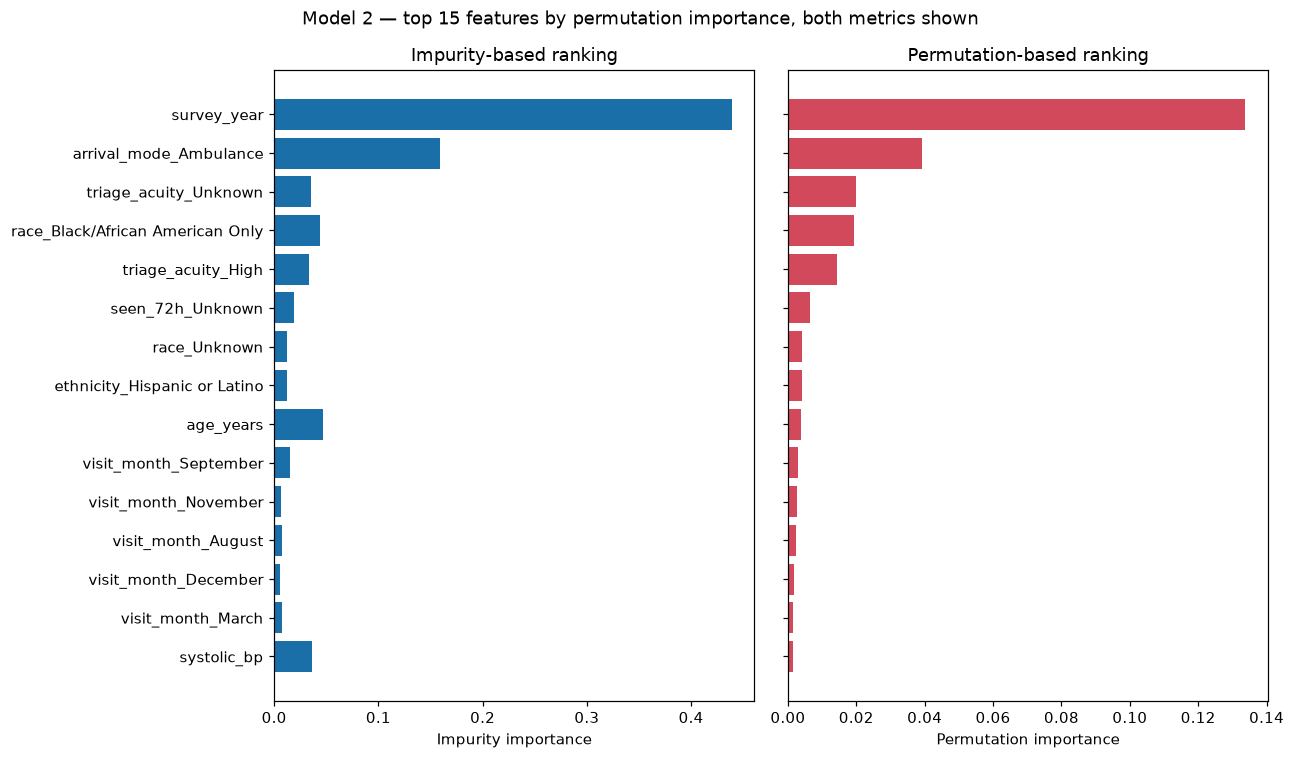

In [6]:
# Impurity importance sums to 1.0 across all features; permutation importance
# is an R² drop on a much smaller scale — plotting them on one shared axis
# would make permutation importance look artificially negligible. Two panels
# with independent x-scales, same feature order (by permutation rank) on
# both, so rank position is still directly comparable side by side.
top_n = 15
top_features = perm2_importances.head(top_n).index[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True)

axes[0].barh(top_features, imp2.reindex(top_features), color="#1B6FA8")
axes[0].set_xlabel("Impurity importance")
axes[0].set_title("Impurity-based ranking")

axes[1].barh(top_features, perm2_importances.reindex(top_features), color="#D1495B")
axes[1].set_xlabel("Permutation importance")
axes[1].set_title("Permutation-based ranking")

fig.suptitle("Model 2 — top 15 features by permutation importance, both metrics shown")
plt.tight_layout()
plt.show()

Same feature order (by permutation rank) in both panels, but each keeps its
own x-scale rather than sharing one axis — impurity importance sums to 1.0
across all features while permutation importance is a much smaller R² drop,
so forcing them onto a single scale would make permutation importance look
artificially negligible. Reading the two panels side by side: `systolic_bp`
ranks in impurity's top 4 but drops far down the permutation panel, and
`pulse` (not shown — outside the permutation top 15) would rank even lower
— confirming visually that impurity importance overstates continuous
features relative to the more trustworthy permutation measure.
`survey_year` and `arrival_mode_Ambulance` are large in both panels, which
is why they're trustworthy as the top two regardless of method.

Partial dependence — what does the non-linearity look like?

`MODELING.md` frames Random Forest's value as capturing non-linear
relationships OLS misses. Partial dependence plots show *what shape* that
non-linearity takes for the two largest continuous drivers (`survey_year`,
`age_years`) and the two largest categorical drivers
(`arrival_mode_Ambulance`, `triage_acuity_High`), holding all other
features at their observed distribution. Computed on a 30,000-row sample
of the Model 2 training set for speed.

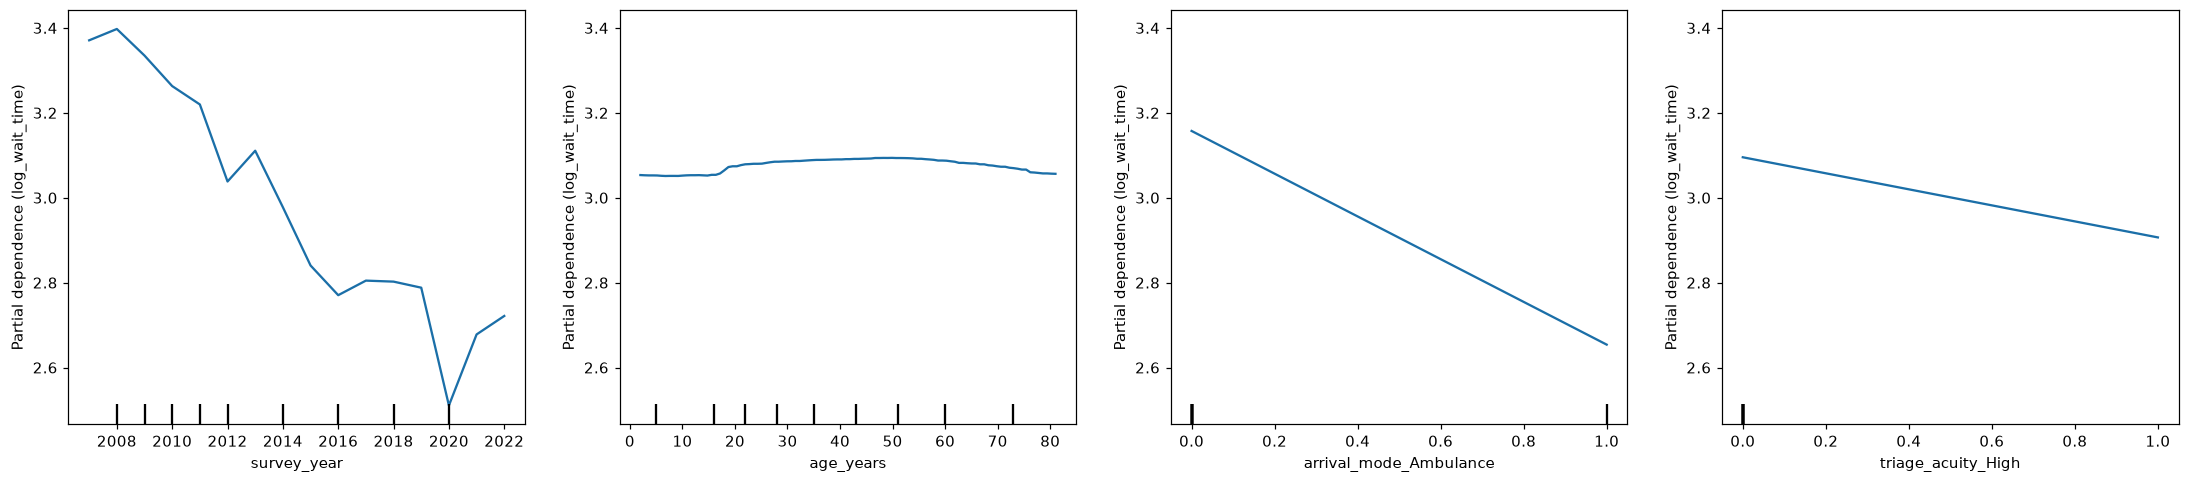

In [7]:
from sklearn.inspection import PartialDependenceDisplay

pdp_sample = X2_train.sample(30000, random_state=42).astype(float)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
PartialDependenceDisplay.from_estimator(
    rf2, pdp_sample,
    ["survey_year", "age_years", "arrival_mode_Ambulance", "triage_acuity_High"],
    ax=axes, line_kw={"color": "#1B6FA8"},
)
for ax in axes:
    ax.set_ylabel("Partial dependence (log_wait_time)")
plt.tight_layout()
plt.show()

**Findings — shape of the non-linear effects**

- `survey_year`: not a straight line down — wait times drop steadily from
  2007 to roughly 2016, flatten and even tick up slightly 2016-2019, then
  fall sharply into 2020 (the partial dependence curve's minimum) before
  partially rebounding 2021-2022. A linear OLS coefficient forces a single
  average slope through this shape and can't represent the 2020 dip
  (plausibly a COVID-era effect: fewer non-urgent ED visits competing for
  the same capacity) or the flat 2016-2019 stretch.
- `age_years`: nearly flat overall (partial dependence ranges only
  ~3.05-3.10), with a slight hump in the 20-50 range — consistent with the
  OLS finding that `age_years` was a comparatively weak, near-zero
  predictor once other features are in the model. Random Forest agrees
  there isn't much hidden non-linear signal in age specifically.
- `arrival_mode_Ambulance` and `triage_acuity_High`: by construction, a
  binary feature's partial dependence is just two points connected by a
  line — both show the same direction as their OLS/Lasso coefficients
  (ambulance and high-acuity both predict shorter waits), which is a
  useful cross-check that Random Forest and the linear models agree on
  *direction* even where they disagree on how much overall variance is
  explained.

## Summary

1. **Random Forest R² is substantially higher than OLS/Lasso** on both
   feature sets (Model 1: 0.092 vs 0.074; Model 2: 0.108 vs 0.078) — per
   `MODELING.md`'s decision rule, this means the demographic, access, and
   clinical variables have real non-linear/interaction structure that the
   linear models' functional form misses, particularly around
   `survey_year`'s non-monotonic trend (the 2020 dip) and the
   High/Medium/Low triage acuity effects the EDA already flagged as
   non-monotonic.
2. **Impurity-based feature importance is misleading here** and should not
   be reported on its own — it inflates continuous features (`survey_year`,
   `age_years`, vitals) relative to one-hot dummies purely due to split
   granularity. Permutation importance is the corrected, trustworthy
   ranking: `survey_year` and `arrival_mode_Ambulance` remain the two
   largest predictors either way, but `triage_acuity_*` rises and the raw
   vitals (`pulse`, `systolic_bp`) fall once the bias is corrected.
3. **Cross-model agreement on direction and on what doesn't matter:**
   Random Forest, Lasso, and OLS all agree that `residence_Other
   institution` and `residence_Other residence` carry no signal, and all
   three agree on the *sign* of every shared top-ranked feature (ambulance
   arrival and high triage acuity shorten waits; Black race and Hispanic
   ethnicity lengthen them). The three methods disagree on relative
   *magnitude* rankings, which is expected given their different
   assumptions, not a contradiction.
4. **This does not overturn the equity finding** — it corroborates it a
   third way. `race_Black/African American Only` and `ethnicity_Hispanic
   or Latino` both retain real, non-impurity-inflated importance under
   permutation testing even after `survey_year`, `arrival_mode`, and every
   clinical variable are in the model and allowed to interact non-linearly.
   If clinical need fully explained the racial/ethnic gap, a flexible
   non-linear model given every opportunity to capture that relationship
   would show it — it doesn't.
5. Per `MODELING.md` Step 6: R² in the 0.05-0.20 range is expected for this
   outcome regardless of model class — even Random Forest's improvement
   over OLS still leaves ~89% of variance unexplained, consistent with
   hospital-level factors (staffing, bed availability) that NHAMCS doesn't
   record at the visit level. The research value remains in the coefficient
   and importance *patterns*, not in predictive accuracy.